In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import ListedColormap
from sklearn.datasets import (
    make_classification,
    make_regression,
    make_moons,
    make_blobs,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from itertools import product as iter_product

np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 11,
})
print("All imports loaded.")

All imports loaded.


---
# 1) Bias-Variance Tradeoff

Every learner's expected prediction error can be decomposed into three irreducible components:

$$
Expected Error = \text{Bias}^2 + \text{Variance} + \text{Noise}
$$

| Term | Meaning |
|------|---------|
| **Bias²** | How far the *average* prediction is from the true function (systematic error) |
| **Variance** | How much predictions *vary* across different training sets (sensitivity to data) |
| **Noise** | Irreducible error in the data itself |


![](https://miro.medium.com/v2/resize:fit:1400/1*kL55QzQVBtUqnQi_NnYZVQ.png)

In [ ]:
def bias_variance_decomposition(
    X_train, y_train, X_test, y_test, model_factory, num_bootstraps=200
):
    '''
    Compute bias^2, variance, and noise via bootstrap resampling.
    Returns (mean_bias2, mean_variance, mean_mse) averaged over test points.
    '''

    num_samples_train = X_train.shape[0]
    num_test = X_test.shape[0]

    # predictions from each bootstrap model
    # (num_bootstraps, num_test)
    all_preds = np.zeros((num_bootstraps, num_test))

    for b in range(num_bootstraps):
        # Bootstrap resample of training data
        idx = np.random.choice(
            num_samples_train,
            size=num_samples_train,
            replace=True
        )
        X_b, y_b = X_train[idx], y_train[idx]

        model = model_factory()
        model.fit(X_b, y_b)

        # (num_test,)
        all_preds[b] = model.predict(X_test)

    # average prediction across bootstraps
    # (num_bootstraps, num_test) -> (num_test,)
    mean_pred = all_preds.mean(axis=0)

    # bias^2 at each test point
    # (num_test,)
    bias2 = (y_test - mean_pred) ** 2

    # variance at each test point
    # (num_test,)
    variance = all_preds.var(axis=0)

    # Scalar averages over test points
    mean_bias2 = bias2.mean()
    mean_variance = variance.mean()
    mean_mse = np.mean((all_preds - y_test[np.newaxis, :]) ** 2)

    return mean_bias2, mean_variance, mean_mse

In [ ]:
# Generate a nonlinear 1-D regression problem
np.random.seed(42)
num_samples = 300
X_all = np.sort(np.random.uniform(-3, 3, num_samples)).reshape(-1, 1)
noise_std = 0.5

# True function: sin with polynomial component
f_true = np.sin(X_all.ravel()) + 0.3 * X_all.ravel() ** 2
y_all = f_true + np.random.randn(num_samples) * noise_std

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)

# Sweep over model complexity (tree depth)
depths = list(range(1, 16))
bias2_list, var_list, mse_list = [], [], []

for d in depths:
    factory = lambda d=d: DecisionTreeRegressor(max_depth=d)
    b2, v, m = bias_variance_decomposition(X_train, y_train, X_test, y_test, factory)
    bias2_list.append(b2)
    var_list.append(v)
    mse_list.append(m)

print(f"Depth  Bias^2   Variance  MSE")
for d, b, v, m in zip(depths, bias2_list, var_list, mse_list):
    print(f"  {d:2d}   {b:.4f}   {v:.4f}   {m:.4f}")

Depth  Bias^2   Variance  MSE
   1   0.7270   0.0690   0.7960
   2   0.4218   0.0967   0.5185
   3   0.2477   0.0883   0.3360
   4   0.2284   0.0918   0.3202
   5   0.2303   0.1085   0.3388
   6   0.2339   0.1167   0.3507
   7   0.2597   0.1264   0.3862
   8   0.2764   0.1376   0.4140
   9   0.2819   0.1421   0.4240
  10   0.3077   0.1471   0.4548
  11   0.3122   0.1464   0.4586
  12   0.3097   0.1494   0.4591
  13   0.3165   0.1481   0.4646
  14   0.3224   0.1439   0.4663
  15   0.3129   0.1486   0.4615


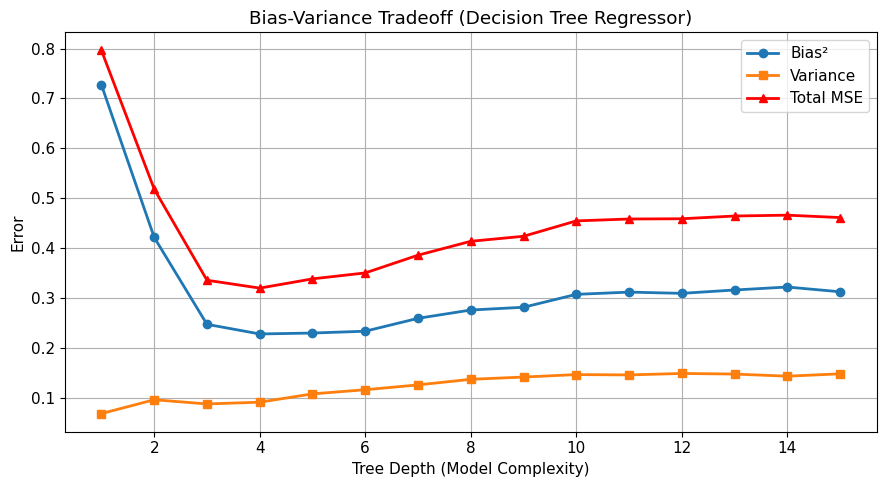

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, bias2_list, "o-", label="Bias\u00b2", linewidth=2)
ax.plot(depths, var_list, "s-", label="Variance", linewidth=2)
ax.plot(depths, mse_list, "^-", label="Total MSE", linewidth=2, color="red")
ax.set_xlabel("Tree Depth (Model Complexity)")
ax.set_ylabel("Error")
ax.set_title("Bias-Variance Tradeoff (Decision Tree Regressor)")
ax.legend()
plt.tight_layout()
plt.show()

---
# 2) Feature Scaling

Many ML algorithms (gradient descent, distance-based methods, regularized models) are sensitive to the *scale* of input features. A feature ranging [0, 1000] will dominate a feature ranging [0, 1] in any distance or gradient computation.

## 2.1 Standard (Z-score) Scaling

$$
z = \frac{x - \mu}{\sigma}
$$

Transforms features to have mean 0 and standard deviation 1.

**Sample I/O**: `[100, 200, 300]` → `[-1.22, 0.0, 1.22]`

**When to use**: Assumes roughly Gaussian distribution. Good default for most algorithms.

In [ ]:
def standardize(X_train, X_test=None):

    # mean and std computed from training set only
    # (num_features,)
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1.0

    # (num_samples, num_features) -> (num_samples, num_features)
    X_train_scaled = (X_train - mean) / std

    if X_test is not None:
        X_test_scaled = (X_test - mean) / std
        return X_train_scaled, X_test_scaled, mean, std

    return X_train_scaled, mean, std


# === Test ===
X_scale_demo = np.array([[100, 0.1], [200, 0.2], [300, 0.3], [400, 0.4]])
X_scaled, mu, sigma = standardize(X_scale_demo)
print("Original:\n", X_scale_demo)
print(f"\nMean: {mu}, Std: {sigma}")
print("Standardized:\n", X_scaled)
print(f"Scaled mean: {X_scaled.mean(axis=0).round(10)}, Scaled std: {X_scaled.std(axis=0).round(4)}")

Original:
 [[1.e+02 1.e-01]
 [2.e+02 2.e-01]
 [3.e+02 3.e-01]
 [4.e+02 4.e-01]]

Mean: [250.     0.25], Std: [111.80339887   0.1118034 ]
Standardized:
 [[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]
Scaled mean: [0. 0.], Scaled std: [1. 1.]


## 2.2 Min-Max Normalization

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Scales features to $[0, 1]$. Sensitive to outliers.

**Sample I/O**: `[100, 200, 300]` → `[0.0, 0.5, 1.0]`

**When to use**: When you need bounded values (e.g., neural network inputs, image pixels).

In [ ]:
def normalize_minmax(X_train, X_test=None):
    # Min-max normalization to [0, 1] (from scratch).
    # Fits on X_train, transforms both.

    # (num_features,)
    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    x_range = x_max - x_min

    # Avoid division by zero
    x_range[x_range == 0] = 1.0

    # (num_samples, num_features) -> (num_samples, num_features)
    X_train_scaled = (X_train - x_min) / x_range

    if X_test is not None:
        X_test_scaled = (X_test - x_min) / x_range
        return X_train_scaled, X_test_scaled, x_min, x_range

    return X_train_scaled, x_min, x_range

# === Test ===
X_norm, xmin, xrange = normalize_minmax(X_scale_demo)
print("Min-Max Normalized:\n", X_norm)

Min-Max Normalized:
 [[0.         0.        ]
 [0.33333333 0.33333333]
 [0.66666667 0.66666667]
 [1.         1.        ]]


## 2.3 Robust Scaling

$$x_{\text{robust}} = \frac{x - \text{median}}{IQR}$$

where $IQR = Q_3 - Q_1$ (interquartile range). Robust to outliers.

**Sample I/O**: `[1, 2, 3, 100]` → `[-0.5, 0.0, 0.5, 49.0]` (outlier 100 doesn't distort scaling of majority)

**When to use**: When data contains significant outliers.

In [ ]:
def robust_scale(X_train, X_test=None):
    # Robust scaling using median and IQR (from scratch).
    # Fits on X_train, transforms both.

    # (num_features,)
    median = np.median(X_train, axis=0)
    q1 = np.percentile(X_train, 25, axis=0)
    q3 = np.percentile(X_train, 75, axis=0)
    iqr = q3 - q1

    # Avoid division by zero
    iqr[iqr == 0] = 1.0

    # (num_samples, num_features) -> (num_samples, num_features)
    X_train_scaled = (X_train - median) / iqr

    if X_test is not None:
        X_test_scaled = (X_test - median) / iqr
        return X_train_scaled, X_test_scaled, median, iqr

    return X_train_scaled, median, iqr

# === Test ===
X_outlier = np.array([[1, 10], [2, 20], [3, 30], [4, 40], [100, 1000]])
X_robust, med, iqr_vals = robust_scale(X_outlier)
print("Original:\n", X_outlier)
print(f"\nMedian: {med}, IQR: {iqr_vals}")
print("Robust Scaled:\n", X_robust)

Original:
 [[   1   10]
 [   2   20]
 [   3   30]
 [   4   40]
 [ 100 1000]]

Median: [ 3. 30.], IQR: [ 2. 20.]
Robust Scaled:
 [[-1.  -1. ]
 [-0.5 -0.5]
 [ 0.   0. ]
 [ 0.5  0.5]
 [48.5 48.5]]


**When to Use Which**

| Scaler | Outlier Robust? | Range | Best For |
|--------|----------------|-------|----------|
| Standardization | No | Unbounded | General purpose, Gaussian-like features |
| Min-Max | No | [0, 1] | Neural nets, bounded features |
| Robust | **Yes** | Unbounded | Data with outliers |

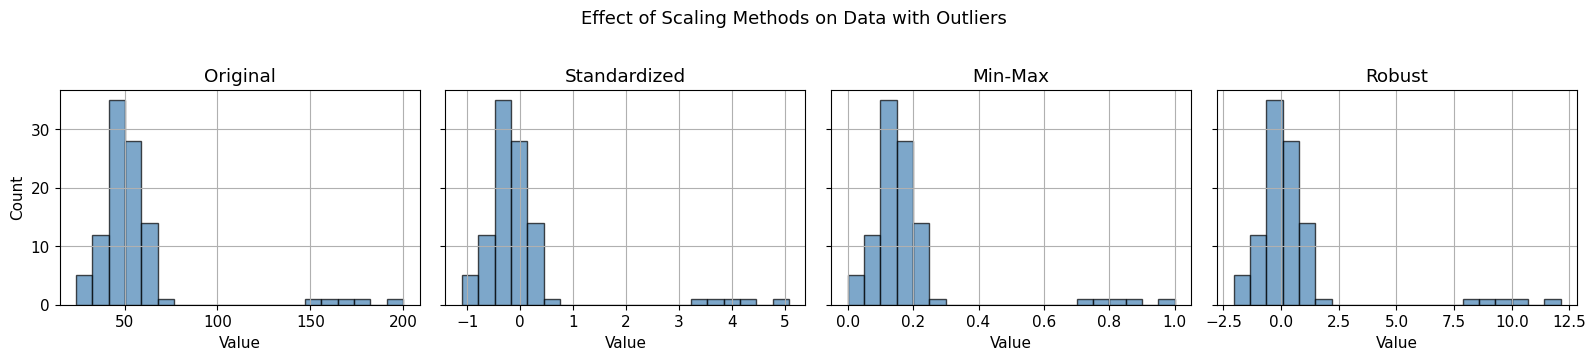

In [ ]:
# Visual comparison of all three scaling methods on data with outlier
np.random.seed(42)

# normal data + outliers
# (num_samples,)
data_scale = np.concatenate([np.random.normal(50, 10, 95), [150, 200, 180, 160, 170]])
data_scale = data_scale.reshape(-1, 1)

data_standard, _, _ = standardize(data_scale)
data_minmax, _, _ = normalize_minmax(data_scale)
data_robust, _, _ = robust_scale(data_scale)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
datasets = [data_scale, data_standard, data_minmax, data_robust]
titles = ["Original", "Standardized", "Min-Max", "Robust"]

for ax, d, t in zip(axes, datasets, titles):
    ax.hist(d, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_title(t)
    ax.set_xlabel("Value")

axes[0].set_ylabel("Count")
plt.suptitle("Effect of Scaling Methods on Data with Outliers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# 3) Encoding Categorical Variables

**Why it matters**: Most ML algorithms operate on numerical arrays. Categorical features must be transformed into numbers, but naive approaches (e.g., label encoding ordinal values as 1, 2, 3) can introduce false ordinal relationships.

## 3.1 One-Hot Encoding

Converts each category into a binary column. For a feature with $k$ categories, creates $k$ (or $k-1$) binary features.

**Sample I/O**: `["red", "blue", "green"]` →
```
red  blue  green
 1     0     0
 0     1     0
 0     0     1
```

**Limitation**: High cardinality → very high dimensionality (curse of dimensionality).

In [ ]:
def one_hot_encode(values, categories=None):
    # One-hot encode a 1-D array of categorical values (from scratch).
    # Returns encoded: (num_samples, num_categories) binary array, and categories list.
    values = np.asarray(values)

    if categories is None:
        categories = sorted(set(values))

    num_samples = len(values)
    num_categories = len(categories)

    # Map category -> index
    cat_to_idx = {cat: i for i, cat in enumerate(categories)}

    # (num_samples, num_categories) -- binary encoding
    encoded = np.zeros((num_samples, num_categories), dtype=int)
    for i, val in enumerate(values):
        if val in cat_to_idx:
            encoded[i, cat_to_idx[val]] = 1

    return encoded, list(categories)


colors = np.array(["red", "blue", "green", "red", "green", "blue", "red"])
encoded, cats = one_hot_encode(colors)
print(f"Categories: {cats}")
print(f"Input:   {colors}")
print(f"Encoded ({encoded.shape}):\n{encoded}")

Categories: [np.str_('blue'), np.str_('green'), np.str_('red')]
Input:   ['red' 'blue' 'green' 'red' 'green' 'blue' 'red']
Encoded ((7, 3)):
[[0 0 1]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]]


## 3.2 Target Encoding (Mean Encoding)

Replaces each category with the *mean of the target variable* for that category. More compact than one-hot for high-cardinality features.

**Sample I/O**:
```
city     price
NYC      500
NYC      600
LA       300
LA       350
```
→ `NYC → 550.0, LA → 325.0`

**Risk**: Overfitting — must use smoothing or compute on training folds to avoid data leakage.

In [ ]:
def target_encode(train_values, train_target, test_values=None, smoothing=10.0):
    '''
    Smoothing: encoding = (count * cat_mean + smoothing * global_mean) / (count + smoothing)
    Returns train_encoded, [test_encoded], encoding_map
    '''

    train_values = np.asarray(train_values)
    train_target = np.asarray(train_target, dtype=float)

    # Scalar - global mean of target
    global_mean = train_target.mean()

    # Build encoding map with smoothing
    encoding_map = {}
    for cat in set(train_values):
        mask = train_values == cat
        cat_mean = train_target[mask].mean()
        count = mask.sum()
        encoding_map[cat] = (
            (count * cat_mean + smoothing * global_mean) /
            (count + smoothing)
        )

    # (num_samples_train,)
    train_encoded = np.array([encoding_map[v] for v in train_values])

    if test_values is not None:
        test_values = np.asarray(test_values)
        # Unknown categories get global mean
        test_encoded = np.array(
            [encoding_map.get(v, global_mean) for v in test_values]
        )
        return train_encoded, test_encoded, encoding_map

    return train_encoded, encoding_map


cities = np.array(["NYC", "NYC", "NYC", "LA", "LA", "SF", "SF", "SF", "SF"])
prices = np.array([500, 600, 550, 300, 350, 400, 420, 380, 410])

enc_vals, emap = target_encode(cities, prices, smoothing=5.0)
print("Target Encoding Map:")
for city, val in sorted(emap.items()):
    print(f"  {city}: {val:.2f}")
print(f"\nOriginal:  {cities}")
print(f"Encoded:   {enc_vals.round(2)}")

Target Encoding Map:
  LA: 403.17
  NYC: 477.78
  SF: 420.25

Original:  ['NYC' 'NYC' 'NYC' 'LA' 'LA' 'SF' 'SF' 'SF' 'SF']
Encoded:   [477.78 477.78 477.78 403.17 403.17 420.25 420.25 420.25 420.25]


## 3.3 Entity Embeddings

For very high-cardinality features (e.g., zip codes, user IDs), **entity embeddings** learn a dense, low-dimensional representation via a neural network.

Each category $c$ maps to a trainable vector $e_c \in \mathbb{R}^d$ (typically $d \ll k$ where $k$ is the number of categories).

**Advantages**:
- Captures semantic similarity between categories (e.g., nearby zip codes get similar embeddings)
- Much more compact than one-hot for high cardinality
- End-to-end trainable with the downstream task

**Rule of thumb for embedding dimension**: $d \approx \min(50, \lceil k/2 \rceil)$

> This concept is foundational for modern deep learning on tabular data (e.g., TabNet, SAINT).

---
# 4) Handling Missing Data

## Types of Missingness

| Type | Abbreviation | Meaning | Example |
|------|-------------|---------|---------|
| Missing Completely At Random | **MCAR** | Missingness unrelated to any variable | Lab sample accidentally dropped |
| Missing At Random | **MAR** | Missingness depends on *observed* variables | Higher income → less likely to report income, but we observe income bracket |
| Missing Not At Random | **MNAR** | Missingness depends on the *missing value itself* | People with very high debt don't report debt |

**Why it matters**: The type of missingness determines which imputation strategies are valid. MCAR is the easiest; MNAR requires domain-specific modeling.

## 4.1 Mean/Median Imputation

Replace missing values with the column mean (or median). Simple but can distort distributions and underestimate variance.

**Sample I/O**: `[1.0, NaN, 3.0, 4.0]` → mean impute → `[1.0, 2.67, 3.0, 4.0]`

In [ ]:
def impute_mean(X):
    # Replace NaN with column mean (from scratch).
    # Returns X_imputed: (num_samples, num_features) and col_means: (num_features,).
    X_imputed = X.copy()

    # compute mean ignoring NaN
    # (num_features,)
    col_means = np.nanmean(X, axis=0)

    for j in range(X.shape[1]):
        mask = np.isnan(X_imputed[:, j])
        X_imputed[mask, j] = col_means[j]

    return X_imputed, col_means


def impute_median(X):
    '''
    Replace NaN with column median (from scratch).
    Returns X_imputed: (num_samples, num_features) and col_medians: (num_features,).
    '''

    X_imputed = X.copy()

    # compute median ignoring NaN
    # (num_features,)
    col_medians = np.nanmedian(X, axis=0)

    for j in range(X.shape[1]):
        mask = np.isnan(X_imputed[:, j])
        X_imputed[mask, j] = col_medians[j]

    return X_imputed, col_medians


# Demo
X_missing = np.array([
    [1.0, 10.0],
    [2.0, np.nan],
    [np.nan, 30.0],
    [4.0, 40.0],
    [5.0, np.nan],
])

X_mean_imp, means = impute_mean(X_missing)
X_median_imp, medians = impute_median(X_missing)

print("Original:\n", X_missing)
print(f"\nMean imputed (means={means.round(2)}):\n", X_mean_imp)
print(f"\nMedian imputed (medians={medians.round(2)}):\n", X_median_imp)

Original:
 [[ 1. 10.]
 [ 2. nan]
 [nan 30.]
 [ 4. 40.]
 [ 5. nan]]

Mean imputed (means=[ 3.   26.67]):
 [[ 1.         10.        ]
 [ 2.         26.66666667]
 [ 3.         30.        ]
 [ 4.         40.        ]
 [ 5.         26.66666667]]

Median imputed (medians=[ 3. 30.]):
 [[ 1. 10.]
 [ 2. 30.]
 [ 3. 30.]
 [ 4. 40.]
 [ 5. 30.]]


## 4.2 KNN Imputation

For each missing value, find the $k$ nearest neighbors (using only non-missing features for distance) and impute with their average.

Captures local structure better than global mean/median.

**Algorithm**:
1. For row $i$ with missing feature $j$: identify rows with non-missing feature $j$
2. Compute distances using features that are non-missing in *both* rows
3. Take the $k$ nearest neighbors and average their values of feature $j$

In [ ]:
def impute_knn(X, num_neighbors=3):
    '''
    KNN imputation for missing values (from scratch).
    Uses Euclidean distance over jointly observed features.
    Returns X_imputed: (num_samples, num_features) with NaN replaced.
    '''

    X_imputed = X.copy()
    num_samples, num_features = X.shape

    for i in range(num_samples):

        # find missing cols for that row
        missing_cols = np.where(np.isnan(X_imputed[i]))[0]
        if len(missing_cols) == 0:
            continue

        for j in missing_cols:
            # Find rows that have non-NaN value for feature j
            candidate_rows = np.where(~np.isnan(X[:, j]))[0]
            if len(candidate_rows) == 0:
                X_imputed[i, j] = np.nanmean(X[:, j])
                continue

            # Features that are non-NaN in row i
            observed_in_i = np.where(~np.isnan(X[i]))[0]

            # distances: (len(candidate_rows),)
            dists = np.full(len(candidate_rows), np.inf)

            for idx, cr in enumerate(candidate_rows):
                # Features observed in both row i and row cr
                shared = observed_in_i[~np.isnan(X[cr, observed_in_i])]
                if len(shared) == 0:
                    continue
                # Euclidean distance over shared features
                dists[idx] = np.sqrt(np.sum((X[i, shared] - X[cr, shared]) ** 2))

            # Select k nearest
            k = min(num_neighbors, np.sum(np.isfinite(dists)))
            if k == 0:
                X_imputed[i, j] = np.nanmean(X[:, j])
                continue

            nearest_idx = candidate_rows[np.argsort(dists)[:k]]

            # Impute with average of k nearest neighbors' values for feature j
            X_imputed[i, j] = np.mean(X[nearest_idx, j])

    return X_imputed


X_knn_imp = impute_knn(X_missing, num_neighbors=2)
print("KNN Imputed (k=2):\n", X_knn_imp)

KNN Imputed (k=2):
 [[ 1.  10. ]
 [ 2.  25. ]
 [ 2.5 30. ]
 [ 4.  40. ]
 [ 5.  25. ]]


---
# 5) Class Imbalance

When one class vastly outnumbers others (e.g., 99% negative, 1% positive in fraud detection), a naive model can achieve 99% accuracy by always predicting the majority class.

## Why Accuracy Fails

| | Predicted Neg | Predicted Pos |
|---|---|---|
| **Actual Neg** (990) | 990 | 0 |
| **Actual Pos** (10) | 10 | 0 |

Accuracy = 99%, but **recall = 0%** — the model is useless for the minority class.

Metrics that matter:
- **Precision**: $\frac{TP}{TP + FP}$
- **Recall**: $\frac{TP}{TP + FN}$
- **F1-score**: $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$
- **AUROC**: Area under the ROC curve — threshold-independent

## 5.1 SMOTE (Synthetic Minority Over-sampling Technique)

**Algorithm**:
1. For each minority sample $x_i$, find its $k$ nearest minority neighbors
2. Pick one neighbor $x_{\text{nn}}$ at random
3. Generate synthetic sample: $x_{\text{new}} = x_i + \lambda (x_{\text{nn}} - x_i)$, where $\lambda \sim U(0, 1)$

This creates new synthetic minority samples *along line segments* between existing minority points.

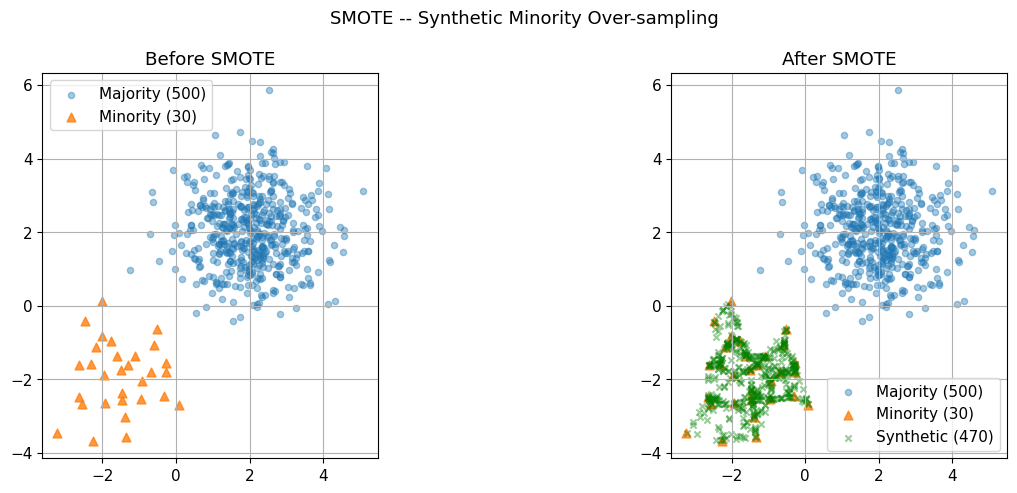

In [ ]:
def smote(X_minority, num_synthetic, num_neighbors=5):
    '''
    SMOTE: generate synthetic minority samples (from scratch).
    X_minority: (num_minority, num_features)
    Returns X_synthetic: (num_synthetic, num_features).
    '''

    num_minority, num_features = X_minority.shape
    k = min(num_neighbors, num_minority - 1)

    # pairwise distances
    # (num_minority, num_minority)
    dists = cdist(X_minority, X_minority, metric='euclidean')

    # indices of k nearest neighbors (excluding self)
    # (num_minority, k)
    nn_indices = np.argsort(dists, axis=1)[:, 1 : k + 1]

    # (num_synthetic, num_features)
    X_synthetic = np.zeros((num_synthetic, num_features))

    for i in range(num_synthetic):
        # Pick a random minority sample
        base_idx = np.random.randint(0, num_minority)

        # Pick a random neighbor of that sample
        nn_idx = nn_indices[base_idx, np.random.randint(0, k)]

        # Interpolate between base and neighbor
        lam = np.random.rand()
        # (num_features,)
        X_synthetic[i] = (
            X_minority[base_idx] + lam *
            (X_minority[nn_idx] - X_minority[base_idx])
        )

    return X_synthetic


# Create imbalanced dataset
np.random.seed(42)
# (num_samples_majority, 2)
X_majority = np.random.randn(500, 2) + np.array([2, 2])
# (num_samples_minority, 2)
X_minor = np.random.randn(30, 2) + np.array([-2, -2])

# Generate synthetic minority samples
X_synth = smote(X_minor, num_synthetic=470, num_neighbors=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
axes[0].scatter(X_majority[:, 0], X_majority[:, 1], alpha=0.4, label="Majority (500)", s=20)
axes[0].scatter(X_minor[:, 0], X_minor[:, 1], alpha=0.8, label="Minority (30)", s=40, marker="^")
axes[0].set_title("Before SMOTE")
axes[0].legend()
axes[0].set_aspect("equal")

# After SMOTE
axes[1].scatter(X_majority[:, 0], X_majority[:, 1], alpha=0.4, label="Majority (500)", s=20)
axes[1].scatter(X_minor[:, 0], X_minor[:, 1], alpha=0.8, label="Minority (30)", s=40, marker="^")
axes[1].scatter(X_synth[:, 0], X_synth[:, 1], alpha=0.4, label="Synthetic (470)", s=20, marker="x", color="green")
axes[1].set_title("After SMOTE")
axes[1].legend()
axes[1].set_aspect("equal")

plt.suptitle("SMOTE -- Synthetic Minority Over-sampling", fontsize=13)
plt.tight_layout()
plt.show()

## 5.2 Focal Loss

Standard cross-entropy:

$$
{CE}(p_t) = -\log(p_t)
$$

**Focal loss** (Lin et al., 2017):

$$
{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)
$$

where $p_t$ is the predicted probability for the true class.

The $(1-p_t)^\gamma$ factor *down-weights easy examples* (high $p_t$) and *up-weights hard examples* (low $p_t$).

With $\gamma = 0$, it reduces to standard CE.

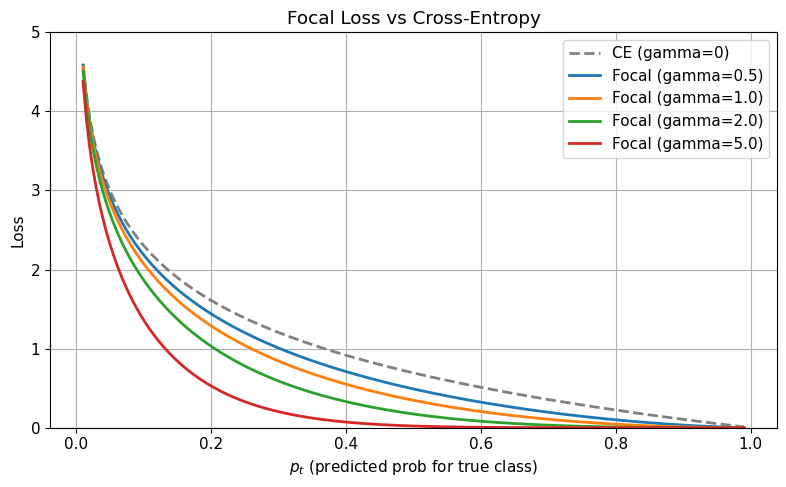

In [ ]:
def focal_loss(y_true, y_pred_prob, gamma=2.0, alpha=0.25):
    '''
    Compute focal loss for binary classification
    y_true: (num_samples,) binary labels {0, 1}
    y_pred_prob: (num_samples,) predicted probabilities for class 1
    Returns (mean_loss, per_sample_loss).
    '''

    # Clip for numerical stability
    p = np.clip(y_pred_prob, 1e-7, 1 - 1e-7)

    # p_t: predicted prob for the TRUE class
    # (num_samples,)
    p_t = np.where(y_true == 1, p, 1 - p)

    # alpha_t: class balancing factor
    # (num_samples,)
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)

    # focal weight
    # (num_samples,)
    focal_weight = (1 - p_t) ** gamma

    # per-sample focal loss
    # (num_samples,)
    per_sample_loss = -alpha_t * focal_weight * np.log(p_t)

    return per_sample_loss.mean(), per_sample_loss


# Visualize focal loss vs standard CE for varying p_t
p_t_range = np.linspace(0.01, 0.99, 200)

fig, ax = plt.subplots(figsize=(8, 5))

# Standard CE
ce_loss = -np.log(p_t_range)
ax.plot(p_t_range, ce_loss, "--", label="CE (gamma=0)", linewidth=2, color="gray")

# Focal loss with different gamma values
for gamma in [0.5, 1.0, 2.0, 5.0]:
    fl = -(1 - p_t_range) ** gamma * np.log(p_t_range)
    ax.plot(p_t_range, fl, label=f"Focal (gamma={gamma})", linewidth=2)

ax.set_xlabel("$p_t$ (predicted prob for true class)")
ax.set_ylabel("Loss")
ax.set_title("Focal Loss vs Cross-Entropy")
ax.legend()
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

## 5.3 Class Weights

Simplest approach: multiply the loss of each sample by the inverse class frequency.

$$w_c = \frac{n_{\text{total}}}{k \cdot n_c}$$

where $k$ is the number of classes and $n_c$ is the count of class $c$. Most sklearn classifiers support `class_weight='balanced'`.

In [ ]:
# Create imbalanced binary classification dataset
np.random.seed(42)
X_imb, y_imb = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    random_state=42,
)
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42
)

print(f"Train class distribution: {dict(zip(*np.unique(y_tr_imb, return_counts=True)))}")
print(f"Test class distribution:  {dict(zip(*np.unique(y_te_imb, return_counts=True)))}")

# === Baseline: no correction ===
lr_baseline = LogisticRegression(max_iter=1000).fit(X_tr_imb, y_tr_imb)

# === Class weights ===
lr_weighted = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_tr_imb, y_tr_imb)

# === SMOTE + Logistic Regression ===
minority_mask = y_tr_imb == 1
majority_mask = y_tr_imb == 0
X_minority_tr = X_tr_imb[minority_mask]
X_majority_tr = X_tr_imb[majority_mask]
num_to_generate = majority_mask.sum() - minority_mask.sum()
X_synth_tr = smote(X_minority_tr, num_synthetic=num_to_generate, num_neighbors=5)
X_tr_smote = np.vstack([X_tr_imb, X_synth_tr])
y_tr_smote = np.concatenate([y_tr_imb, np.ones(num_to_generate)])
lr_smote = LogisticRegression(max_iter=1000).fit(X_tr_smote, y_tr_smote)

# Evaluate all methods
results = {}
for name, model in [("Baseline", lr_baseline), ("Class Weights", lr_weighted), ("SMOTE", lr_smote)]:
    y_pred = model.predict(X_te_imb)
    y_prob = model.predict_proba(X_te_imb)[:, 1]
    results[name] = {
        "F1": f1_score(y_te_imb, y_pred),
        "AUROC": roc_auc_score(y_te_imb, y_prob),
        "Recall": classification_report(y_te_imb, y_pred, output_dict=True)["1"]["recall"],
    }

print("\n{:<16} {:>8} {:>8} {:>8}".format("Method", "F1", "AUROC", "Recall"))
print("-" * 42)
for name, metrics in results.items():
    print(f"{name:<16} {metrics['F1']:>8.4f} {metrics['AUROC']:>8.4f} {metrics['Recall']:>8.4f}")

Train class distribution: {np.int64(0): np.int64(1319), np.int64(1): np.int64(81)}
Test class distribution:  {np.int64(0): np.int64(573), np.int64(1): np.int64(27)}

Method                 F1    AUROC   Recall
------------------------------------------
Baseline           0.0000   0.7851   0.0000
Class Weights      0.2059   0.7996   0.7778
SMOTE              0.2051   0.8001   0.7407


---
# 6) Feature Selection

Removing irrelevant/redundant features reduces overfitting, speeds up training, and improves interpretability.

Three families:
1. **Filter**: Score features independently (fast, model-agnostic)
2. **Wrapper**: Evaluate subsets using a model (slower, more accurate)
3. **Embedded**: Feature selection built into training (e.g., L1, tree importance)

## 6.1 Filter Methods: Mutual Information (from scratch)

**Mutual Information** measures the *statistical dependency* between a feature $X$ and target $Y$:

$$
I(X; Y) = \sum_{x}\sum_{y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}
$$

$I(X;Y) = 0$ iff $X$ and $Y$ are independent. Unlike correlation, MI captures *nonlinear* dependencies.

For continuous features, we discretize into bins and compute the discrete MI.

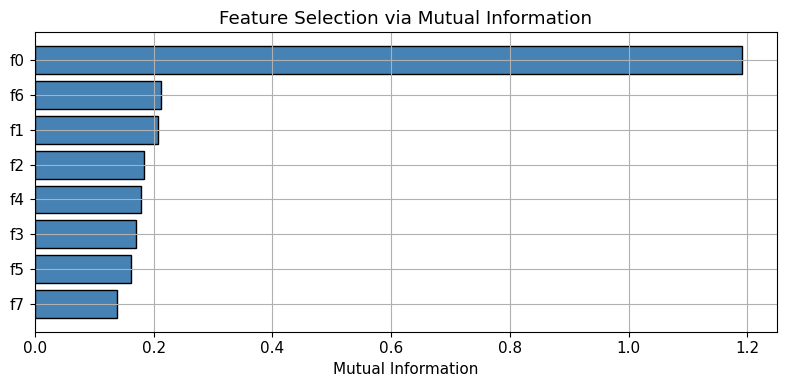

MI scores: {'f0': '1.1905', 'f1': '0.2072', 'f2': '0.1836', 'f3': '0.1702', 'f4': '0.1786', 'f5': '0.1626', 'f6': '0.2125', 'f7': '0.1381'}


In [ ]:
def mutual_information(X, y, num_bins=10):
    '''
    Compute mutual information between each feature and target.
    Uses histogram-based density estimation (discretization).
    X: (num_samples, num_features), y: (num_samples,)
    Returns mi_scores: (num_features,)
    '''

    num_samples, num_features = X.shape
    mi_scores = np.zeros(num_features)

    # Discretize target
    y_bins = np.digitize(y, np.linspace(y.min(), y.max(), num_bins + 1)[1:-1])

    for j in range(num_features):
        # Discretize feature j
        x_col = X[:, j]
        x_bins = np.digitize(x_col, np.linspace(x_col.min(), x_col.max(), num_bins + 1)[1:-1])

        # Joint distribution p(x, y)
        joint_counts = np.zeros((num_bins, num_bins))
        for i in range(num_samples):
            xb = min(x_bins[i], num_bins - 1)
            yb = min(y_bins[i], num_bins - 1)
            joint_counts[xb, yb] += 1

        # (num_bins, num_bins) -- joint probability
        p_xy = joint_counts / num_samples

        # (num_bins,) -- marginals
        p_x = p_xy.sum(axis=1)
        p_y = p_xy.sum(axis=0)

        # MI = sum p(x,y) * log(p(x,y) / (p(x)*p(y)))
        mi = 0.0
        for xi in range(num_bins):
            for yi in range(num_bins):
                if p_xy[xi, yi] > 0 and p_x[xi] > 0 and p_y[yi] > 0:
                    mi += p_xy[xi, yi] * np.log(p_xy[xi, yi] / (p_x[xi] * p_y[yi]))

        mi_scores[j] = mi

    return mi_scores


# Features with varying relevance
np.random.seed(42)
num_samples_fs = 500
X_fs = np.random.randn(num_samples_fs, 8)

# Feature 0: strong linear relation to target
# Feature 1: strong nonlinear relation
# Feature 2: weak relation
# Features 3-7: pure noise
y_fs = 3 * X_fs[:, 0] + np.sin(4 * X_fs[:, 1]) + 0.2 * X_fs[:, 2] + np.random.randn(num_samples_fs) * 0.5

mi_scores = mutual_information(X_fs, y_fs, num_bins=15)

feature_names = [f"f{i}" for i in range(8)]
sorted_idx = np.argsort(mi_scores)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(8), mi_scores[sorted_idx], color="steelblue", edgecolor="black")
ax.set_yticks(range(8))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel("Mutual Information")
ax.set_title("Feature Selection via Mutual Information")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("MI scores:", {feature_names[i]: f"{mi_scores[i]:.4f}" for i in range(8)})

## 6.2 Recursive Feature Elimination

**RFE Algorithm**:
1. Train model on all features
2. Rank features by importance (e.g., absolute coefficient values)
3. Remove the least important feature
4. Repeat until desired number of features reached

In [ ]:
def recursive_feature_elimination(X, y, model_factory, num_features_to_select=3):
    '''
    Recursive Feature Elimination (from scratch).
    Returns selected_indices, ranking: (num_features,), elimination_order.
    '''

    num_features = X.shape[1]
    remaining = list(range(num_features))
    ranking = np.ones(num_features, dtype=int)
    elimination_order = []
    step = 0

    while len(remaining) > num_features_to_select:
        # Train model on remaining features
        model = model_factory()
        model.fit(X[:, remaining], y)

        # feature importances
        # (len(remaining),)
        importances = np.abs(model.coef_).ravel()

        # Find least important feature
        least_important_local = np.argmin(importances)
        least_important_global = remaining[least_important_local]

        # Record elimination
        step += 1
        elimination_order.append((step, least_important_global))
        ranking[least_important_global] = num_features - len(remaining) + 2

        # Remove feature
        remaining.pop(least_important_local)

    # Selected features get rank 1
    for idx in remaining:
        ranking[idx] = 1

    return remaining, ranking, elimination_order


# Run RFE on our feature selection dataset
selected, ranking, elim_order = recursive_feature_elimination(
    X_fs, y_fs,
    model_factory=lambda: LinearRegression(),
    num_features_to_select=3,
)

print(f"Selected features: {[feature_names[i] for i in selected]}")
print(f"\nFeature rankings (1 = selected):")
for i in range(8):
    print(f"  {feature_names[i]}: rank {ranking[i]}")
print(f"\nElimination order:")
for step, idx in elim_order:
    print(f"  Step {step}: eliminated {feature_names[idx]}")

Selected features: ['f0', 'f2', 'f4']

Feature rankings (1 = selected):
  f0: rank 1
  f1: rank 4
  f2: rank 1
  f3: rank 2
  f4: rank 1
  f5: rank 5
  f6: rank 6
  f7: rank 3

Elimination order:
  Step 1: eliminated f3
  Step 2: eliminated f7
  Step 3: eliminated f1
  Step 4: eliminated f5
  Step 5: eliminated f6


## 6.3 Embedded Methods (brief)

Embedded methods perform feature selection as part of training:

- **L1 regularization** (Lasso): Zeroes out irrelevant features directly (see Section 4)
- **Tree-based importance**: Random forests/gradient boosting measure how much each feature improves splits
- **Attention weights**: Transformers can learn which features to attend to

These are generally preferable when you have a specific downstream model, since they select features optimized for that model.

In [ ]:
# Compare Filter (MI) vs Wrapper (RFE) selections
print("Feature Selection Comparison:")
print(f"{'Feature':<8} {'MI Score':<12} {'MI Rank':<10} {'RFE Rank':<10}")
print("-" * 40)

mi_ranking = np.argsort(np.argsort(-mi_scores)) + 1
for i in range(8):
    marker = "  << selected by both" if mi_ranking[i] <= 3 and ranking[i] == 1 else ""
    print(f"{feature_names[i]:<8} {mi_scores[i]:<12.4f} {mi_ranking[i]:<10} {ranking[i]:<10}{marker}")

Feature Selection Comparison:
Feature  MI Score     MI Rank    RFE Rank  
----------------------------------------
f0       1.1905       1          1           << selected by both
f1       0.2072       3          4         
f2       0.1836       4          1         
f3       0.1702       6          2         
f4       0.1786       5          1         
f5       0.1626       7          5         
f6       0.2125       2          6         
f7       0.1381       8          3         


---
# 7) Outlier Detection

**Outliers** are data points that deviate significantly from the expected pattern. They can be genuine anomalies (fraud) or data errors (sensor malfunction). Detection is critical for:
- Data cleaning (remove errors)
- Anomaly detection (find interesting cases)
- Robust modeling (reduce influence of extreme points)

## 7.1 Statistical Methods (Z-score, IQR)

**Z-score method**: Flag points where $|z_j| > \theta$ (common $\theta = 3$):
$$z = \frac{x - \mu}{\sigma}$$

**IQR method**: Flag points outside $[Q_1 - 1.5 \cdot IQR, \; Q_3 + 1.5 \cdot IQR]$

**Sample I/O**: `[1, 2, 3, 2, 100]` → Z-score flags `100`; IQR flags `100`

In [ ]:
def detect_outliers_zscore(X, threshold=3.0):
    # Detect outliers using Z-score method (from scratch).
    # Returns is_outlier: (num_samples,) boolean, z_scores: (num_samples, num_features).

    # (num_features,)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0

    # (num_samples, num_features) -- absolute Z-scores
    z_scores = np.abs((X - mean) / std)

    # A point is an outlier if ANY feature exceeds threshold
    # (num_samples,)
    is_outlier = np.any(z_scores > threshold, axis=1)
    return is_outlier, z_scores

def detect_outliers_iqr(X, factor=1.5):
    # Detect outliers using IQR method (from scratch).
    # Returns is_outlier: (num_samples,) boolean.

    # (num_features,)
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)
    iqr = q3 - q1

    # (num_features,) -- bounds
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    # (num_samples,) -- outlier if any feature is outside bounds
    is_outlier = np.any((X < lower) | (X > upper), axis=1)

    return is_outlier


# === Test ===
np.random.seed(42)
X_normal = np.random.randn(100, 2)
# Add outliers
X_outliers_pts = np.array([[5, 5], [-5, -4], [4, -5], [-4, 6], [6, -6]])
X_combined = np.vstack([X_normal, X_outliers_pts])

zscore_mask, _ = detect_outliers_zscore(X_combined, threshold=2.5)
iqr_mask = detect_outliers_iqr(X_combined, factor=1.5)

print(f"Z-score detected {zscore_mask.sum()} outliers")
print(f"IQR detected {iqr_mask.sum()} outliers")

Z-score detected 5 outliers
IQR detected 6 outliers


## 7.2 Isolation Forest

Outliers are *easier to isolate*. In a random tree that splits on random features at random values, outliers require fewer splits to be isolated into a single-point leaf.

**Algorithm**:
1. Build an ensemble of random isolation trees
2. For each tree: recursively partition data by picking a random feature and random split value
3. The **anomaly score** is based on the average path length to isolate a point:

$$
s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}
$$

where $h(x)$ is the path length,

$c(n) = 2H(n-1) - 2(n-1)/n$

is the average path length in a BST, and $H$ is the harmonic number.

- $s \approx 1$: definite anomaly (short path)
- $s \approx 0.5$: normal (average path)
- $s \ll 0.5$: very normal (long path)

In [ ]:
class IsolationTreeNode:
    def __init__(self, split_feature=None, split_value=None, left=None, right=None, size=0):
        self.split_feature = split_feature
        self.split_value = split_value
        self.left = left
        self.right = right
        self.size = size

def _c(n):
    # Average path length of unsuccessful search in BST (normalization factor).
    if n <= 1:
        return 0.0
    h = np.log(n - 1) + 0.5772156649
    return 2.0 * h - 2.0 * (n - 1) / n


def build_isolation_tree(X, max_depth, current_depth=0):
    '''
    Build a single isolation tree (from scratch).
    X: (num_samples, num_features), max_depth: int
    Returns IsolationTreeNode.
    '''

    num_samples, num_features = X.shape

    # Base case: single sample or max depth reached
    if num_samples <= 1 or current_depth >= max_depth:
        return IsolationTreeNode(size=num_samples)

    # Select random feature and find feature range
    feat = np.random.randint(0, num_features)
    feat_min, feat_max = X[:, feat].min(), X[:, feat].max()

    if feat_min == feat_max:
        return IsolationTreeNode(size=num_samples)

    # Pick random split value within that feature's range
    split_val = np.random.uniform(feat_min, feat_max)

    # Partition
    left_mask = X[:, feat] < split_val
    right_mask = ~left_mask

    node = IsolationTreeNode(
        split_feature=feat,
        split_value=split_val,
        left=build_isolation_tree(X[left_mask], max_depth, current_depth + 1),
        right=build_isolation_tree(X[right_mask], max_depth, current_depth + 1),
        size=num_samples,
    )

    return node


def path_length(x, node, current_depth=0):
    '''
    Compute path length for a single point in an isolation tree.
    x: (num_features,), returns estimated path length (scalar).
    '''

    if node.left is None and node.right is None:
        return current_depth + _c(node.size)

    if x[node.split_feature] < node.split_value:
        return path_length(x, node.left, current_depth + 1)
    else:
        return path_length(x, node.right, current_depth + 1)


class IsolationForest:
    def __init__(self, num_trees=100, subsample_size=256):
        self.num_trees = num_trees
        # To choose subset of full data
        self.subsample_size = subsample_size
        self.trees = []

    def fit(self, X):
        # Build the isolation forest. X: (num_samples, num_features).
        num_samples = X.shape[0]
        max_depth = int(np.ceil(np.log2(self.subsample_size)))

        self.trees = []
        for _ in range(self.num_trees):
            idx = np.random.choice(
                num_samples, size=min(self.subsample_size, num_samples), replace=False
            )
            tree = build_isolation_tree(X[idx], max_depth)
            self.trees.append(tree)
        return self

    def anomaly_score(self, X):
        '''
        Compute anomaly scores. X: (num_samples, num_features).
        Returns scores: (num_samples,) in [0, 1]. Close to 1 = anomaly.
        '''

        num_samples = X.shape[0]
        # (num_samples,) -- average path length across all trees
        avg_path_lengths = np.zeros(num_samples)

        for tree in self.trees:
            for i in range(num_samples):
                avg_path_lengths[i] += path_length(X[i], tree)

        avg_path_lengths /= self.num_trees
        c_n = _c(self.subsample_size)

        # (num_samples,) -- anomaly score: s(x, n) = 2^(-E[h(x)] / c(n))
        scores = 2.0 ** (-avg_path_lengths / c_n)
        return scores

    def predict(self, X, threshold=0.6):
        # Predict outlier labels. Returns (num_samples,) with 1=outlier, 0=normal.
        scores = self.anomaly_score(X)
        return (scores > threshold).astype(int)

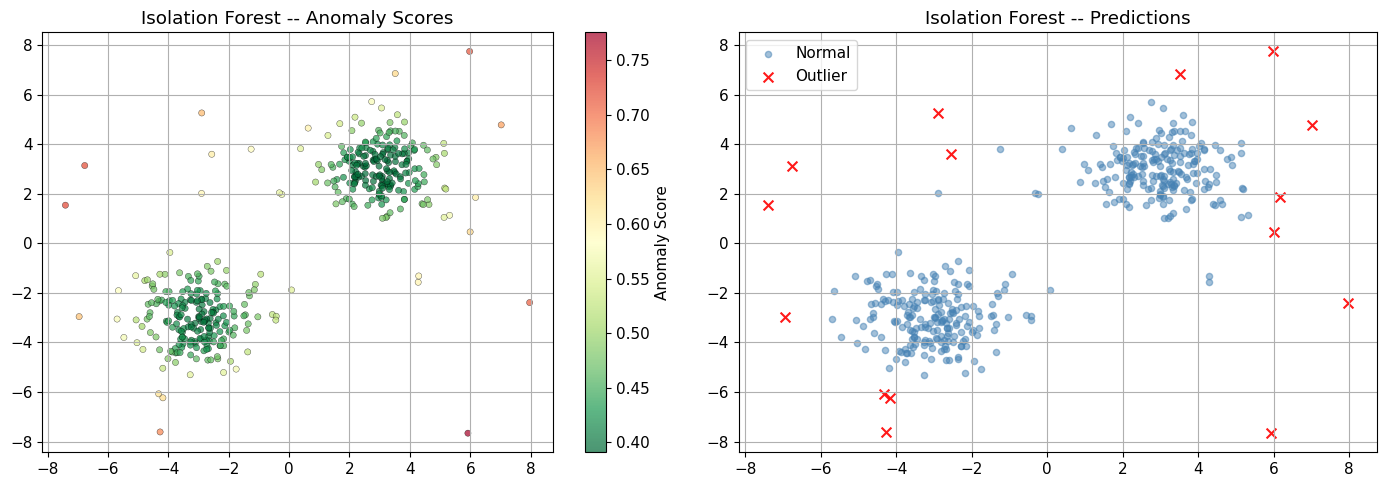

Detected 15 outliers out of 420 points
True outliers: 20


In [ ]:
# === Test ===
np.random.seed(42)

# Normal data: two clusters
X_normal_1 = np.random.randn(200, 2) + np.array([3, 3])
X_normal_2 = np.random.randn(200, 2) + np.array([-3, -3])

# Outliers: scattered
X_outlier_pts = np.random.uniform(-8, 8, size=(20, 2))

X_iforest = np.vstack([X_normal_1, X_normal_2, X_outlier_pts])
true_labels = np.concatenate([np.zeros(400), np.ones(20)])

# Fit Isolation Forest
iforest = IsolationForest(num_trees=100, subsample_size=256)
iforest.fit(X_iforest)

# (num_samples,) -- anomaly scores
scores = iforest.anomaly_score(X_iforest)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: anomaly scores as color
scatter = axes[0].scatter(
    X_iforest[:, 0], X_iforest[:, 1], c=scores, cmap="RdYlGn_r",
    s=20, alpha=0.7, edgecolors="k", linewidths=0.3,
)
plt.colorbar(scatter, ax=axes[0], label="Anomaly Score")
axes[0].set_title("Isolation Forest -- Anomaly Scores")

# Right: predicted anomalies
preds = iforest.predict(X_iforest, threshold=0.6)
normal_mask = preds == 0
outlier_mask = preds == 1
axes[1].scatter(
    X_iforest[normal_mask, 0], X_iforest[normal_mask, 1],
    s=20, alpha=0.5, label="Normal", color="steelblue",
)
axes[1].scatter(
    X_iforest[outlier_mask, 0], X_iforest[outlier_mask, 1],
    s=50, alpha=0.9, label="Outlier", color="red", marker="x",
)
axes[1].set_title("Isolation Forest -- Predictions")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Detected {outlier_mask.sum()} outliers out of {len(X_iforest)} points")
print(f"True outliers: {int(true_labels.sum())}")

| Method | Type | Handles Local Outliers? | Complexity | Interpretable? |
|--------|------|-------------------------|------------|----------------|
| Z-score | Statistical | No | $O(n)$ | Very |
| IQR | Statistical | No | $O(n)$ | Very |
| Isolation Forest | Tree-based | Partially | $O(n \log n)$ | Moderate |
| LOF | Density-based | **Yes** | $O(n^2)$ | Moderate |